# Veri Temizleme (data cleaning/cleasing)
## Gürültülü Veri
- Gürültülü veri ne demektir: Cinsiyeti Erkek olan bir kişinin Aynı zamanda hamile olması durumudur. Yanlış bilgi içermesidir

- Mesela bir bebek biberonun değeri 1 milyon dolar olmaz. Bozuk/Yanlış/ayrıkı durumdur.

- Birbiri ile çelişkili durumları ifade etmektedir.
  
## Eksik Veri Analizi
- Verideki eksiklikler
  
## Aykırı Gözlem Analizi
- Verideki aykırılıklar

# Veri Standardizasyonu
- 0-1 Dönüşümü
- z-skoru dönüşümü
- Logaritmik dönüşüm

# Veri İndirgeme
- Gözlem sayısının azaltılması
- Dağişken sayısının azaltılması
# Değişken dönüştürme
- Sürekli değişkenlerde dönüşümler
- Kategorik değişkenlerde dönüşümler
  

# Aykırı Gözlem Analizi Giriş
## Aykırı Gözlem
- Veride genel eğilimin oldukça dışına çıkan ya da diğer gözlemlerden oldukça farklı olan gözlemlere aykırı gözlem denir.
# Aykırı Değer Nedir
- Aykırılığı ifade eden nümerik değere aykırı değer denir.
- Aykırı değeri barındıran gözlem birimine aykırı gözlem denir. outlier / sıradışı değer/ uç değer gibi isimlendirmelerle karşımıza gelir.
## Aykırı değer neye sebep olur?
- Genellenebilirlik kaygısı ile oluşturulan kural setlerini ya da fonksiyonlarını yanıltır. Yanlılığa sebep olur.

## Kime Göre Neye Göre Aykırı
- Veri setinin genel eğiliminin dışına çıkmayı nasıl tanımlarız?
- Veri setinin genel eğilimin dışına çıkmayı nasıl tanımlarız.
  1. Sektör bilgisi. Örnegin ev fiyat tahmin modelinde 1000 m2 lik evleri modellemeye almamak. Genellenebilir modeller oluşturmak olacak. Tr deki evleirn pek çoğu 2+1 ve 3+1 dir. O zaman genellemede bunların dışında kalan bilgileri ihmal etmek olacaktır.
  * **Not**: Eğer kurulan modelin bir genelleme kaygısı varsa; zaten çok seyrek olan senaryolar ve genele uymayan yapılar çalışmnın dışında bırakılmalıdır.
  2. Standart Sapma Yaklaşımı : Bir değişkenin ortalamasının üzerine aynı değişkenin standart sapması hesaplanarak eklenir. 1,2 ya da 3 standart sapma değeri ortalama üzerine eklenerek ortaya çıkan bu değer eşik değer olarak düşünülür ve bu değerden yukarı ya da aşağıda olan değerler aykırı değer olarak tanımlanır.

    **Eşik Değer** = **Ortalama** + **n** X **Standart Sapma**  *n = 1,2,3.*
  * Ortalama : Verinin Merkezi eğilimi.
  * Standart Sapma : Dağılım. Ortalama etrafındaki yapılanmasını ifade eden değer.
  3. Z-Skoru Yaklaşımı : Std sapma yöntemine benzer şekilde çalışır. Değişken std sapma normal dağılımına uyarlanır, yani standartlaştırılır. Sonrasında -örneğin- dağılımın sağından ve solundan -+2.5 değerine göre bir eşik değer konulur ve bu değerin üzerinde ya da altında olan değerler aykırı değer olarak işaretlenir.
  4. Boxplot (interquartile range -IQR) Yöntemi : En sık kullanılan yöntemlerden birisidir. Değişkenin değerleri küçükten büyüğe sıralanır. Çeyrekliklerine (yüzdeliklerine) yani Q1, Q3 değerlerine karşılık değerler üzerinden bir eşik değer hesaplanır ve bu eşik değere göre aykırı değer tanımı yapılır.
    
    

# Aykırı Gözlem Analizi
## Aykırı Değerleri Yakalamak

In [90]:
import seaborn as sns
df = sns.load_dataset("diamonds")
df = df.select_dtypes(include = ["float","int64"])
df = df.dropna() # eksik gözlemleri sildik
df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [92]:
df_table = df["table"]
df_table.head()

0    55.0
1    61.0
2    65.0
3    58.0
4    58.0
Name: table, dtype: float64

<Axes: xlabel='table'>

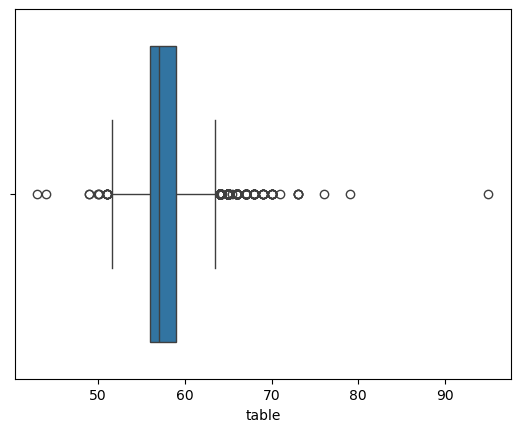

In [94]:
sns.boxplot(x = df_table)
# grafigin sag ve sol tarafındaki değerler aykırı değer olarak değerlendirilecek.

In [96]:
Q1 = df_table.quantile(0.25) # değişkenin küçükten büyüge sıralandıgında değişkenim %25 . indexe karsılık gelen degeri ifade eder
Q3 =df_table.quantile(0.75) # % 75. index karsılık gelen deger
IQR = Q3 - Q1 # inter quartile %75 index ten %25 index farkı olarak bulunur

In [98]:
Q1

56.0

In [100]:
Q3

59.0

In [102]:
IQR # 3. ceyre kdegerden 1. ceyrek degeri cıkarınca elde edilir.

3.0

In [104]:
alt_sinir = Q1 -1.5 * IQR # birinci ceyrek degerden 1.5 * IQR kadar aşagısını alt sınır olarak belirle
ust_sinir = Q3 +1.5*IQR # 3. ceyrek degere 1.5*IQR kadar yukarısını ust sınır olarak belirle

In [106]:
alt_sinir

51.5

In [108]:
ust_sinir

63.5

In [110]:
(df_table < alt_sinir) | (df_table > ust_sinir) # ya alt_sinir kucuk olanlar ya da ust_sinir büyük olanlar 

0        False
1        False
2         True
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: table, Length: 53940, dtype: bool

In [112]:
aykiri_tf = df_table < alt_sinir
aykiri_tf.head()

0    False
1    False
2    False
3    False
4    False
Name: table, dtype: bool

In [114]:
df_table[aykiri_tf] # fancy index

1515     51.0
3238     50.1
3979     51.0
4150     51.0
5979     49.0
7418     50.0
8853     51.0
11368    43.0
22701    49.0
25179    50.0
26387    51.0
33586    51.0
35633    44.0
45798    51.0
46040    51.0
47630    51.0
Name: table, dtype: float64

In [116]:
df_table[aykiri_tf].index #  index erisme

Index([ 1515,  3238,  3979,  4150,  5979,  7418,  8853, 11368, 22701, 25179,
       26387, 33586, 35633, 45798, 46040, 47630],
      dtype='int64')

# Aykırı Değerlerle nasıl bas ederiz
    1. yaklasım Silme

In [149]:
import pandas as pd

In [151]:
type(df_table)

pandas.core.frame.DataFrame

In [153]:
df_table = pd.DataFrame(df_table)

In [155]:
df_table.shape

(53940, 1)

In [163]:
temiz_df = df_table[~ ((df_table < alt_sinir) | (df_table > ust_sinir)).any(axis=1)] # ~ aykırı olmayan degerleri al. tersi anlamına geliyor
# alt sını altında ya da ust sınıt ustunde olan degerler dısındakileri al. axis =1 sutun bazında islem yaptık
temiz_df

,table
0,55.0
1,61.0
3,58.0
4,58.0
5,57.0
...,...
53935,57.0
53936,55.0
53937,60.0
53938,58.0


In [165]:
temiz_df.shape

(53335, 1)

# Ortalama ile Doldurma

In [170]:
import seaborn as sns
df = sns.load_dataset("diamonds")
df = df.select_dtypes(include = ["float","int64"])
df = df.dropna() # eksik gözlemleri sildik
df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [174]:
aykiri_tf.head()

0    False
1    False
2    False
3    False
4    False
Name: table, dtype: bool

In [176]:
# aykırıları ortalama ile dolduracagız
df_table[aykiri_tf]

1515     51.0
3238     50.1
3979     51.0
4150     51.0
5979     49.0
7418     50.0
8853     51.0
11368    43.0
22701    49.0
25179    50.0
26387    51.0
33586    51.0
35633    44.0
45798    51.0
46040    51.0
47630    51.0
Name: table, dtype: float64

In [180]:
df_table.mean()

57.45718390804598

In [188]:
df_table[aykiri_tf] = df_table.mean()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9708\3741757661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_table[aykiri_tf] = df_table.mean()


In [190]:
df_table[aykiri_tf] # aykırı degerler ortalama ile dolduruldu

1515     57.459506
3238     57.459506
3979     57.459506
4150     57.459506
5979     57.459506
7418     57.459506
8853     57.459506
11368    57.459506
22701    57.459506
25179    57.459506
26387    57.459506
33586    57.459506
35633    57.459506
45798    57.459506
46040    57.459506
47630    57.459506
Name: table, dtype: float64

# Baskılama yöntemi
1. aykırıları sildik
2. aykırıları ortalama ile doldurduk
3. Baskılama : Aykırılar yakalandıktan sonra üst taraftaysa üst sınır degerine eşitlenir. Alt taraftaysa alt sınır degerine eşitlenir. Örnegine aykırı deger 100 olson. ust deger 60 ve ortalam 50 olsun.  aykırı degeri 50 e cekmek yerine ust sınıra baskılamak 60 a daha mantıklı olabilir bazı durumlarda


In [196]:
import seaborn as sns
df = sns.load_dataset("diamonds")
df = df.select_dtypes(include = ["float","int64"])
df = df.dropna() # eksik gözlemleri sildik
df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [198]:
df_table = df["table"]

In [200]:
df_table # aykırı degerler

0        55.0
1        61.0
2        65.0
3        58.0
4        58.0
         ... 
53935    57.0
53936    55.0
53937    60.0
53938    58.0
53939    55.0
Name: table, Length: 53940, dtype: float64